# Static Portfolio Optimization with Cluster Constraints

This notebook performs **static portfolio optimization** for the VN30 universe under a cluster-constrained Markowitz setup.

## Scope

This notebook:
- solves static portfolio optimization problems
- uses `cluster_id` to apply cluster constraints
- uses `mean_ret` as the `mu` vector
- uses `Sigma` from `cov_matrix.csv`
- exports portfolio weights for downstream evaluation

This notebook does **not**:
- create new clusters
- change `K`
- change `cluster_id`
- run a backtest

## Input Data

1. `return_matrix_clean.csv` - daily log-return matrix
2. `cov_matrix.csv` - daily covariance matrix used as `Sigma`
3. `ticker_clusters_enriched.csv` - ticker metadata with `cluster_id`, `mean_ret`, and `std_ret`

## Canonical Outputs

1. `portfolio_weights_static.csv` - GMV defensive portfolio weights
2. `portfolio_weights_aggressive.csv` - aggressive portfolio weights, exported only if the solution passes feasibility checks

## Research Framing

- `mean_ret` is used as a **historical mean daily log-return estimate** and acts as an empirical proxy for expected return.
- Cluster caps are applied on top of the full 29-ticker universe to enforce diversification constraints.
- Any efficient-frontier block later in the notebook is **diagnostic and interpretive**, not a canonical downstream artifact.


In [1]:
# Import libraries
import json
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

print("Imports loaded successfully.")
print(f"cvxpy version: {cp.__version__}")


Imports loaded successfully.
cvxpy version: 1.7.5


## Step 1: Load Inputs and Validate the Ticker Universe


In [2]:
# Setup paths
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
HELPERS_DIR = PROJECT_ROOT / "notebooks" / "helpers"
if str(HELPERS_DIR) not in sys.path:
    sys.path.insert(0, str(HELPERS_DIR))

from static_artifact_contract import (
    build_static_artifact_status,
    clear_canonical_if_present,
    migrate_existing_aggressive_snapshot_once,
    write_static_artifact_status,
)
from static_aggressive_targets import (
    build_aggressive_target_shortlist,
    choose_highest_feasible_target,
)

STATUS_PATH = DATA_PROCESSED / "static_artifact_status.json"
GMV_CANONICAL_PATH = DATA_PROCESSED / "portfolio_weights_static.csv"
AGG_CANONICAL_PATH = DATA_PROCESSED / "portfolio_weights_aggressive.csv"
AGG_LEGACY_PATH = DATA_PROCESSED / "legacy" / "portfolio_weights_aggressive_prefeasibility.csv"

migrated_legacy_once = migrate_existing_aggressive_snapshot_once(AGG_CANONICAL_PATH, AGG_LEGACY_PATH)

# Load inputs
ret = pd.read_csv(DATA_PROCESSED / "return_matrix_clean.csv", index_col=0, parse_dates=True)
cov_matrix = pd.read_csv(DATA_PROCESSED / "cov_matrix.csv", index_col=0)
ticker_info = pd.read_csv(DATA_PROCESSED / "ticker_clusters_enriched.csv")

# Normalize ticker metadata
ticker_info["ticker"] = ticker_info["ticker"].astype(str).str.upper().str.strip()
ticker_info["cluster_id"] = ticker_info["cluster_id"].astype(int)

required_info_cols = {"ticker", "cluster_id", "mean_ret", "std_ret"}
assert required_info_cols.issubset(ticker_info.columns), "ticker_info is missing required columns"
assert ret.shape[0] > 0 and ret.shape[1] > 0, "return_matrix_clean.csv is empty"
assert cov_matrix.shape[0] == cov_matrix.shape[1] > 0, "cov_matrix must be square and non-empty"
assert ticker_info.shape[0] > 0, "ticker_clusters_enriched.csv is empty"
assert ret.columns.nunique() == len(ret.columns), "ret contains duplicate tickers"
assert cov_matrix.index.nunique() == len(cov_matrix.index), "cov_matrix index contains duplicate tickers"
assert cov_matrix.columns.nunique() == len(cov_matrix.columns), "cov_matrix columns contain duplicate tickers"
assert ticker_info["ticker"].nunique() == len(ticker_info), "ticker_info contains duplicate tickers"
assert ticker_info[["mean_ret", "std_ret"]].isna().sum().sum() == 0, "ticker_info contains NaN in mean_ret/std_ret"

assert set(ret.columns) == set(cov_matrix.columns) == set(cov_matrix.index) == set(ticker_info["ticker"]), (
    "Ticker universe mismatch between ret/cov_matrix/ticker_info"
)

print("=" * 72)
print("INPUT VALIDATION")
print("=" * 72)
print("Shapes:")
print(f"  ret:         {ret.shape}")
print(f"  cov_matrix:  {cov_matrix.shape}")
print(f"  ticker_info: {ticker_info.shape}")
print("\nTicker counts:")
print(f"  ret columns:        {len(ret.columns)}")
print(f"  cov rows / columns: {len(cov_matrix.index)} / {len(cov_matrix.columns)}")
print(f"  ticker_info rows:   {len(ticker_info)}")
print("\nUniverse check: PASS")
print(ticker_info.head())

print("\n" + "=" * 72)
print("STATIC ARTIFACT GOVERNANCE SETUP")
print("=" * 72)
print(f"GMV canonical path:        {GMV_CANONICAL_PATH}")
print(f"Aggressive canonical path: {AGG_CANONICAL_PATH}")
print(f"Aggressive legacy path:    {AGG_LEGACY_PATH}")
print(f"Legacy migration run now:  {migrated_legacy_once}")


INPUT VALIDATION
Shapes:
  ret:         (1435, 29)
  cov_matrix:  (29, 29)
  ticker_info: (29, 4)

Ticker counts:
  ret columns:        29
  cov rows / columns: 29 / 29
  ticker_info rows:   29

Universe check: PASS
  ticker  cluster_id  mean_ret   std_ret
0    ACB           1  0.000903  0.018966
1    BID           1  0.000235  0.022525
2    CTG           1  0.000862  0.022311
3    HDB           1  0.001047  0.022045
4    LPB           1  0.002006  0.025968

STATIC ARTIFACT GOVERNANCE SETUP
GMV canonical path:        D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\portfolio_weights_static.csv
Aggressive canonical path: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\portfolio_weights_aggressive.csv
Aggressive legacy path:    D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\legacy\portfolio_weights_aggressive_prefeasibility.csv
Legacy migration run now:  False


In [3]:
# Reorder all inputs to one canonical ticker order
expected_n_tickers = len(ret.columns)
assert expected_n_tickers == len(cov_matrix.index) == len(cov_matrix.columns) == len(ticker_info), (
    "Ticker counts must match before reorder"
)

canonical_tickers = sorted(ret.columns.tolist())
assert len(canonical_tickers) == expected_n_tickers, "Unexpected ticker count after building canonical order"
assert set(canonical_tickers) == set(cov_matrix.index) == set(cov_matrix.columns) == set(ticker_info["ticker"]), (
    "Ticker universe changed before reorder"
)

ret = ret[canonical_tickers]
cov_matrix = cov_matrix.loc[canonical_tickers, canonical_tickers]
ticker_info = ticker_info.set_index("ticker", drop=False).loc[canonical_tickers].reset_index(drop=True)

assert list(ret.columns) == canonical_tickers, "ret columns are not aligned after reorder"
assert list(cov_matrix.index) == canonical_tickers, "cov_matrix index is not aligned after reorder"
assert list(cov_matrix.columns) == canonical_tickers, "cov_matrix columns are not aligned after reorder"
assert list(ticker_info["ticker"]) == canonical_tickers, "ticker_info ticker order is not aligned after reorder"
assert list(ret.columns) == list(cov_matrix.index) == list(cov_matrix.columns) == list(ticker_info["ticker"]), (
    "Ticker order is not fully synchronized after reorder"
)

print("=" * 72)
print("CANONICAL TICKER ORDER")
print("=" * 72)
print(f"Ticker count: {expected_n_tickers}")
print(f"First 5 tickers: {canonical_tickers[:5]}")
print(f"Last 2 tickers: {canonical_tickers[-2:]}")
print("Full reorder synchronization: PASS")


CANONICAL TICKER ORDER
Ticker count: 29
First 5 tickers: ['ACB', 'BCM', 'BID', 'CTG', 'DGC']
Last 2 tickers: ['VPB', 'VRE']
Full reorder synchronization: PASS


## Step 2: Build `mu` and `Sigma` with Explicit Numerical Checks


In [4]:
print("=" * 72)
print("BUILD MU AND SIGMA")
print("=" * 72)

# mu is a historical mean daily log-return estimate.
mu = ticker_info["mean_ret"].to_numpy(dtype=float)
Sigma = cov_matrix.to_numpy(dtype=float)

assert mu.shape == (expected_n_tickers,), "mu has an unexpected shape"
assert Sigma.shape == (expected_n_tickers, expected_n_tickers), "Sigma has an unexpected shape"
assert np.isnan(mu).sum() == 0, "mu contains NaN"
assert np.isnan(Sigma).sum() == 0, "Sigma contains NaN"

symmetry_gap = float(np.abs(Sigma - Sigma.T).max())
assert symmetry_gap <= 1e-10, f"Sigma is not symmetric enough: max gap = {symmetry_gap:.3e}"

eigvals_before = np.linalg.eigvalsh(Sigma)
min_eig_before = float(eigvals_before.min())
max_eig_before = float(eigvals_before.max())
regularization_epsilon = 0.0

if min_eig_before < -1e-10:
    regularization_epsilon = abs(min_eig_before) + 1e-8
    Sigma = Sigma + regularization_epsilon * np.eye(expected_n_tickers)
    eigvals_after = np.linalg.eigvalsh(Sigma)
    min_eig_after = float(eigvals_after.min())
else:
    eigvals_after = eigvals_before
    min_eig_after = min_eig_before

print("mu interpretation:")
print("  - mu is the historical mean daily log-return estimate")
print("  - it is used as an empirical proxy for expected return")
print("\nmu summary:")
print(f"  - shape: {mu.shape}")
print(f"  - mean:  {mu.mean():.6f}")
print(f"  - min:   {mu.min():.6f} ({ticker_info.loc[int(mu.argmin()), 'ticker']})")
print(f"  - max:   {mu.max():.6f} ({ticker_info.loc[int(mu.argmax()), 'ticker']})")
print("\nSigma summary:")
print(f"  - shape: {Sigma.shape}")
print(f"  - symmetry max gap: {symmetry_gap:.3e}")
print(f"  - min eigenvalue before regularization: {min_eig_before:.8f}")
print(f"  - max eigenvalue before regularization: {max_eig_before:.8f}")
print(f"  - regularization epsilon added: {regularization_epsilon:.8e}")
print(f"  - min eigenvalue after regularization: {min_eig_after:.8f}")
print("  - PSD check: PASS" if min_eig_after >= -1e-8 else "  - PSD check: FAIL")


BUILD MU AND SIGMA
mu interpretation:
  - mu is the historical mean daily log-return estimate
  - it is used as an empirical proxy for expected return

mu summary:
  - shape: (29,)
  - mean:  0.000684
  - min:   -0.000446 (SAB)
  - max:   0.002006 (LPB)

Sigma summary:
  - shape: (29, 29)
  - symmetry max gap: 0.000e+00
  - min eigenvalue before regularization: 0.00007610
  - max eigenvalue before regularization: 0.00698303
  - regularization epsilon added: 0.00000000e+00
  - min eigenvalue after regularization: 0.00007610
  - PSD check: PASS


## Step 3: Define Feasibility Tolerances and the GMV Problem


In [5]:
print("=" * 72)
print("FEASIBILITY TOLERANCES AND HELPER LOGIC")
print("=" * 72)

sum_tol = 1e-5
weight_tol = 1e-5
cluster_tol = 1e-5
vol_tol = 1e-5
selection_threshold = 0.001
trading_days = 252


def evaluate_feasibility(weights, ticker_info, cluster_caps, Sigma, vol_cap=None):
    weights = np.asarray(weights, dtype=float).reshape(-1)
    n_nan_weights = int(np.isnan(weights).sum())

    if n_nan_weights > 0:
        weight_sum = np.nan
        weight_sum_error = np.inf
        min_weight = np.nan
        max_cluster_violation = np.inf
        portfolio_vol = np.nan
        vol_violation = np.inf if vol_cap is not None else 0.0
        cluster_allocations = {cid: np.nan for cid in cluster_caps}
        cluster_violations = {cid: np.inf for cid in cluster_caps}
        feasible = False
    else:
        weight_sum = float(weights.sum())
        weight_sum_error = float(abs(weight_sum - 1.0))
        min_weight = float(weights.min())

        cluster_allocations = {}
        cluster_violations = {}
        max_cluster_violation = 0.0
        for cid, cap in cluster_caps.items():
            idx = np.where(ticker_info["cluster_id"].to_numpy() == cid)[0]
            alloc = float(weights[idx].sum()) if len(idx) > 0 else 0.0
            violation = alloc - cap
            cluster_allocations[cid] = alloc
            cluster_violations[cid] = violation
            max_cluster_violation = max(max_cluster_violation, violation)

        portfolio_var = float(weights.T @ Sigma @ weights)
        portfolio_var = max(portfolio_var, 0.0)
        portfolio_vol = float(np.sqrt(portfolio_var))
        vol_violation = float(portfolio_vol - vol_cap) if vol_cap is not None else 0.0

        feasible = (
            weight_sum_error <= sum_tol
            and min_weight >= -weight_tol
            and max_cluster_violation <= cluster_tol
            and (vol_cap is None or vol_violation <= vol_tol)
        )

    return {
        "weight_sum": weight_sum,
        "weight_sum_error": weight_sum_error,
        "min_weight": min_weight,
        "max_cluster_violation": max_cluster_violation,
        "portfolio_vol": portfolio_vol,
        "vol_violation": vol_violation,
        "n_nan_weights": n_nan_weights,
        "cluster_allocations": cluster_allocations,
        "cluster_violations": cluster_violations,
        "feasible": feasible,
    }


def print_feasibility_report(label, metrics, vol_cap=None):
    print(f"{label} feasibility status: {'PASS' if metrics['feasible'] else 'FAIL'}")
    print(f"  - n_nan_weights:         {metrics['n_nan_weights']}")
    print(f"  - weight_sum_error:      {metrics['weight_sum_error']:.8f}")
    print(f"  - min_weight:            {metrics['min_weight']:.8f}")
    print(f"  - max_cluster_violation: {metrics['max_cluster_violation']:.8f}")
    if vol_cap is not None:
        print(f"  - volatility cap:        {vol_cap:.8f}")
        print(f"  - volatility actual:     {metrics['portfolio_vol']:.8f}")
        print(f"  - vol_violation:         {metrics['vol_violation']:.8f}")


print("Tolerance settings:")
print(f"  - sum_tol:     {sum_tol}")
print(f"  - weight_tol:  {weight_tol}")
print(f"  - cluster_tol: {cluster_tol}")
print(f"  - vol_tol:     {vol_tol}")
print(f"  - selection threshold for display: {selection_threshold}")


FEASIBILITY TOLERANCES AND HELPER LOGIC
Tolerance settings:
  - sum_tol:     1e-05
  - weight_tol:  1e-05
  - cluster_tol: 1e-05
  - vol_tol:     1e-05
  - selection threshold for display: 0.001


In [6]:
print("=" * 72)
print("DEFINE CLUSTER CAPS AND GMV CONSTRAINTS")
print("=" * 72)

# Defensive caps remain the canonical baseline.
cluster_caps_defensive = {
    1: 0.50,
    2: 0.40,
    3: 0.20,
    4: 0.50,
}

# Aggressive static gets its own cap profile for the target-return min-variance problem.
cluster_caps_aggressive_static = {
    1: 0.60,
    2: 0.60,
    3: 0.30,
    4: 0.25,
}

# Keep a defensive alias for downstream diagnostics that still reference `cluster_caps`.
cluster_caps = cluster_caps_defensive
qp_solvers = [cp.OSQP, cp.SCS]


def solve_qp_problem(problem):
    last_status = "not_run"
    last_solver = "none"
    for solver in qp_solvers:
        try:
            problem.solve(solver=solver, verbose=False)
            last_status = problem.status
            last_solver = solver if isinstance(solver, str) else solver.__name__
            if problem.status in {"optimal", "optimal_inaccurate"}:
                return last_status, last_solver
        except cp.error.SolverError:
            continue
    return last_status, last_solver


print("Defensive cluster caps for the current clustering snapshot:")
for cid, cap in cluster_caps_defensive.items():
    n_cluster_tickers = int((ticker_info["cluster_id"] == cid).sum())
    print(f"  - Cluster {cid}: cap <= {cap:.2f} ({cap*100:.0f}%), tickers = {n_cluster_tickers}")

print("\nAggressive-static cluster caps:")
for cid, cap in cluster_caps_aggressive_static.items():
    n_cluster_tickers = int((ticker_info["cluster_id"] == cid).sum())
    print(f"  - Cluster {cid}: cap <= {cap:.2f} ({cap*100:.0f}%), tickers = {n_cluster_tickers}")

n = expected_n_tickers
w = cp.Variable(n)
portfolio_var = cp.quad_form(w, Sigma)
objective = cp.Minimize(portfolio_var)
constraints = [cp.sum(w) == 1, w >= 0]

for cid, cap in cluster_caps_defensive.items():
    idx = np.where(ticker_info["cluster_id"].to_numpy() == cid)[0]
    if len(idx) > 0:
        constraints.append(cp.sum(w[idx]) <= cap)

print("\nGMV formulation:")
print("  - Objective: minimize w^T Sigma w")
print("  - Fully invested: sum(w) = 1")
print("  - Long-only: w_i >= 0")
print("  - Cluster constraint: sum(w_i in cluster c) <= cap_c")


DEFINE CLUSTER CAPS AND GMV CONSTRAINTS
Defensive cluster caps for the current clustering snapshot:
  - Cluster 1: cap <= 0.50 (50%), tickers = 12
  - Cluster 2: cap <= 0.40 (40%), tickers = 10
  - Cluster 3: cap <= 0.20 (20%), tickers = 3
  - Cluster 4: cap <= 0.50 (50%), tickers = 4

Aggressive-static cluster caps:
  - Cluster 1: cap <= 0.60 (60%), tickers = 12
  - Cluster 2: cap <= 0.60 (60%), tickers = 10
  - Cluster 3: cap <= 0.30 (30%), tickers = 3
  - Cluster 4: cap <= 0.25 (25%), tickers = 4

GMV formulation:
  - Objective: minimize w^T Sigma w
  - Fully invested: sum(w) = 1
  - Long-only: w_i >= 0
  - Cluster constraint: sum(w_i in cluster c) <= cap_c


In [7]:
print("\nNo target-return constraint is used in the defensive problem.")
print("This notebook solves the cluster-constrained Global Minimum Variance portfolio first.")

gmv_problem = cp.Problem(objective, constraints)
print(f"GMV problem variables: {n}")
print(f"GMV constraint count: {len(constraints)}")



No target-return constraint is used in the defensive problem.
This notebook solves the cluster-constrained Global Minimum Variance portfolio first.
GMV problem variables: 29
GMV constraint count: 6


## Step 4: Solve the GMV Defensive Portfolio


In [8]:
print("=" * 72)
print("SOLVE GMV DEFENSIVE PORTFOLIO")
print("=" * 72)

gmv_solver_status = "not_run"
gmv_solver_name = "none"
gmv_problem_value = np.nan
w_opt = None
gmv_feasibility = None
gmv_feasible = False
gmv_export_allowed = False
result = None
result_filtered = pd.DataFrame()
cluster_alloc = pd.Series(dtype=float)
port_ret = np.nan
port_vol = np.nan
port_sharpe_daily = np.nan
port_sharpe_annual = np.nan
output_file = GMV_CANONICAL_PATH

print("Running solver...")
gmv_solver_status, gmv_solver_name = solve_qp_problem(gmv_problem)
gmv_problem_value = float(gmv_problem.value) if gmv_problem.value is not None else np.nan
w_opt = None if w.value is None else np.asarray(w.value, dtype=float).reshape(-1)

print(f"Solver status: {gmv_solver_status}")
print(f"Solver name:   {gmv_solver_name}")
print(f"Objective value (variance): {gmv_problem_value:.8f}" if not np.isnan(gmv_problem_value) else "Objective value: unavailable")


SOLVE GMV DEFENSIVE PORTFOLIO
Running solver...
Solver status: optimal
Solver name:   OSQP
Objective value (variance): 0.00014407


## Step 5: Validate and Analyze the GMV Solution


In [9]:
print("=" * 72)
print("GMV VALIDATION AND ANALYSIS")
print("=" * 72)

if w_opt is None:
    print("No GMV weights were returned by the solver.")
else:
    gmv_feasibility = evaluate_feasibility(
        weights=w_opt,
        ticker_info=ticker_info,
        cluster_caps=cluster_caps_defensive,
        Sigma=Sigma,
        vol_cap=None,
    )
    gmv_feasible = bool(gmv_feasibility["feasible"])
    gmv_export_allowed = gmv_solver_status in ["optimal", "optimal_inaccurate"] and gmv_feasible

    result = ticker_info.copy()
    result["weight"] = w_opt

    port_ret = float(mu @ w_opt)
    port_vol = float(np.sqrt(max(w_opt.T @ Sigma @ w_opt, 0.0)))
    port_sharpe_daily = port_ret / port_vol if port_vol > 0 else np.nan
    port_sharpe_annual = (port_ret * trading_days) / (port_vol * np.sqrt(trading_days)) if port_vol > 0 else np.nan

    result_filtered = result[result["weight"] > selection_threshold].copy()
    result_filtered = result_filtered.sort_values("weight", ascending=False)
    cluster_alloc = result.groupby("cluster_id")["weight"].sum().sort_index()

    print(f"Solver status:      {gmv_solver_status}")
    print_feasibility_report("GMV", gmv_feasibility)
    print(f"Export decision:    {'EXPORT' if gmv_export_allowed else 'DO NOT EXPORT'}")

    if gmv_feasibility["min_weight"] < 0 and gmv_feasibility["min_weight"] >= -weight_tol:
        print("Note: the negative weight magnitude stays within solver tolerance.")

    print("\nPortfolio statistics:")
    print(f"  - Daily mean log-return proxy: {port_ret:.6f}")
    print(f"  - Annualized mean log-return:  {port_ret * trading_days:.4f} ({port_ret * trading_days * 100:.2f}%)")
    print(f"  - Daily volatility:            {port_vol:.6f}")
    print(f"  - Annualized volatility:       {port_vol * np.sqrt(trading_days):.4f} ({port_vol * np.sqrt(trading_days) * 100:.2f}%)")
    print(f"  - Daily Sharpe (Rf=0):         {port_sharpe_daily:.4f}")
    print(f"  - Annualized Sharpe (Rf=0):    {port_sharpe_annual:.4f}")

    print("\nSelected holdings above the display threshold:")
    print(f"  - Selected tickers: {len(result_filtered)} / {n}")
    if not result_filtered.empty:
        print(result_filtered[["ticker", "cluster_id", "weight", "mean_ret", "std_ret"]].head(15).to_string(index=False))
    else:
        print("  - No holdings above the display threshold.")

    print("\nCluster allocations:")
    for cid, alloc in cluster_alloc.items():
        cap = cluster_caps_defensive.get(int(cid), 1.0)
        used_pct = (alloc / cap * 100) if cap > 0 else np.nan
        violation = gmv_feasibility["cluster_violations"].get(int(cid), np.nan)
        print(f"  - Cluster {int(cid)}: {alloc:.4f} ({alloc*100:.2f}%) | cap = {cap:.2f} | used = {used_pct:.1f}% | violation = {violation:.8f}")


GMV VALIDATION AND ANALYSIS
Solver status:      optimal
GMV feasibility status: PASS
  - n_nan_weights:         0
  - weight_sum_error:      0.00000000
  - min_weight:            -0.00000000
  - max_cluster_violation: 0.00000000
Export decision:    EXPORT
Note: the negative weight magnitude stays within solver tolerance.

Portfolio statistics:
  - Daily mean log-return proxy: 0.000346
  - Annualized mean log-return:  0.0872 (8.72%)
  - Daily volatility:            0.012003
  - Annualized volatility:       0.1905 (19.05%)
  - Daily Sharpe (Rf=0):         0.0288
  - Annualized Sharpe (Rf=0):    0.4575

Selected holdings above the display threshold:
  - Selected tickers: 15 / 29
ticker  cluster_id   weight  mean_ret  std_ret
   VNM           4 0.188959 -0.000082 0.015296
   VJC           4 0.139805  0.000222 0.017899
   SAB           4 0.131727 -0.000446 0.017815
   FPT           2 0.130411  0.001054 0.018127
   VIC           3 0.108782  0.000652 0.021953
   TPB           1 0.074060  0.00

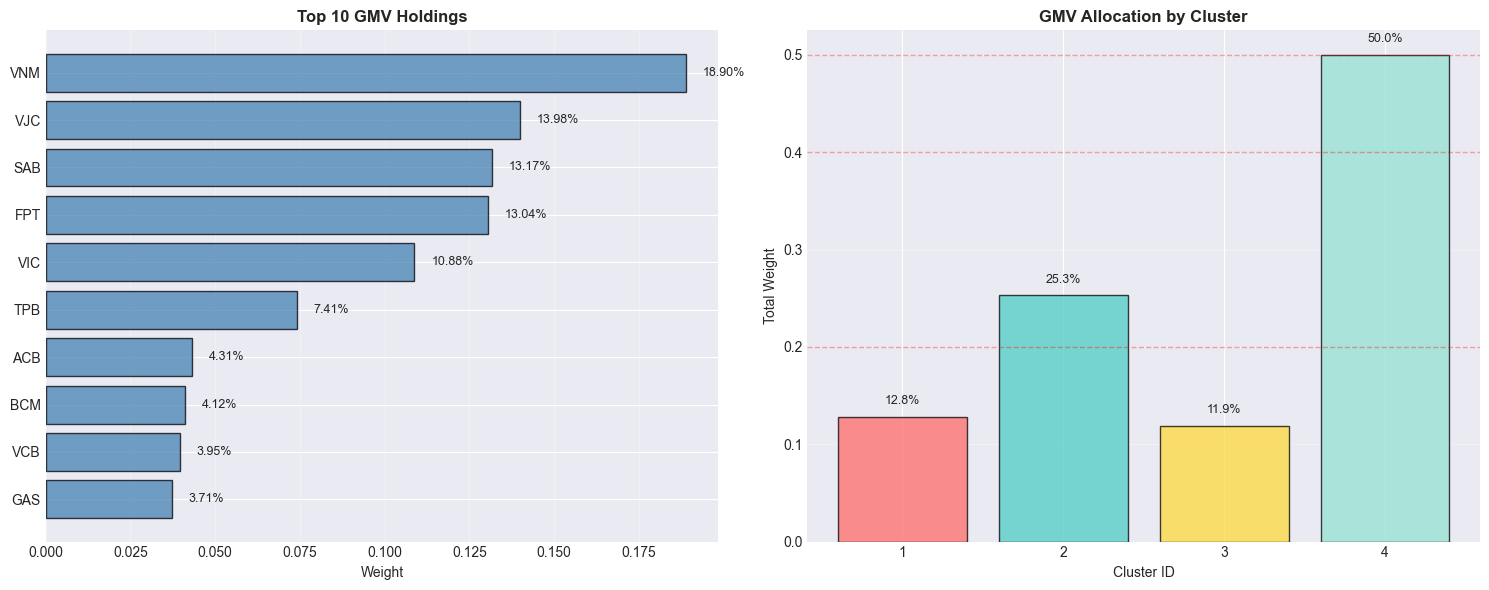

GMV plots rendered.


In [10]:
if result is not None and not result_filtered.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax = axes[0]
    top10 = result_filtered.head(10)
    ax.barh(range(len(top10)), top10["weight"], color="steelblue", alpha=0.75, edgecolor="black")
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10["ticker"])
    ax.set_xlabel("Weight")
    ax.set_title("Top 10 GMV Holdings", fontweight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis="x")
    for i, (_, row) in enumerate(top10.iterrows()):
        ax.text(row["weight"] + 0.005, i, f"{row['weight']*100:.2f}%", va="center", fontsize=9)

    ax = axes[1]
    cluster_ids = cluster_alloc.index.astype(int).astype(str)
    ax.bar(cluster_ids, cluster_alloc.values, color=["#FF6B6B", "#4ECDC4", "#FFD93D", "#95E1D3"][: len(cluster_alloc)], alpha=0.75, edgecolor="black")
    for cap in sorted(set(cluster_caps.values())):
        ax.axhline(y=cap, color="red", linestyle="--", linewidth=1, alpha=0.35)
    ax.set_xlabel("Cluster ID")
    ax.set_ylabel("Total Weight")
    ax.set_title("GMV Allocation by Cluster", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    for i, (_, alloc) in enumerate(cluster_alloc.items()):
        ax.text(i, alloc + 0.01, f"{alloc*100:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()
    print("GMV plots rendered.")
else:
    print("GMV plots skipped because no validated GMV result is available.")


## GMV Holdings by Cluster


## Aggressive Static Portfolio: Target-Return Min-Variance With Cluster Caps


In [11]:
if gmv_export_allowed and result is not None:
    portfolio_weights = result[["ticker", "cluster_id", "weight", "mean_ret", "std_ret"]].copy()
    portfolio_weights = portfolio_weights.sort_values(["cluster_id", "weight"], ascending=[True, False])
    portfolio_weights.to_csv(output_file, index=False)

    print("=" * 72)
    print("EXPORT GMV CANONICAL ARTIFACT")
    print("=" * 72)
    print(f"Exported: {output_file}")
    print("Schema: ticker, cluster_id, weight, mean_ret, std_ret")
    print(f"Rows: {len(portfolio_weights)}")
else:
    print("=" * 72)
    print("GMV EXPORT GATING")
    print("=" * 72)
    print("GMV canonical export was skipped because the solution did not pass feasibility checks.")
    print(f"Target file left untouched: {output_file}")


EXPORT GMV CANONICAL ARTIFACT
Exported: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\portfolio_weights_static.csv
Schema: ticker, cluster_id, weight, mean_ret, std_ret
Rows: 29


## GMV Summary


In [12]:
print("=" * 80)
print("GMV DEFENSIVE SUMMARY")
print("=" * 80)
print(f"Solver status:      {gmv_solver_status}")
print(f"Solver name:        {gmv_solver_name}")
print(f"Feasibility status: {'PASS' if gmv_feasible else 'FAIL'}")
print(f"Export decision:    {'EXPORTED' if gmv_export_allowed else 'NOT EXPORTED'}")

if result is not None:
    print("\nInputs used:")
    print("  - return_matrix_clean.csv")
    print("  - cov_matrix.csv")
    print("  - ticker_clusters_enriched.csv")
    print("\nGMV formulation:")
    print("  - minimize w^T Sigma w")
    print("  - sum(w) = 1")
    print("  - w_i >= 0")
    print("  - sum of weights inside each cluster <= cluster cap")
    print("\nGMV metrics:")
    print(f"  - Annualized return proxy: {port_ret * trading_days * 100:.2f}%")
    print(f"  - Annualized volatility:   {port_vol * np.sqrt(trading_days) * 100:.2f}%")
    print(f"  - Annualized Sharpe (Rf=0): {port_sharpe_annual:.4f}")
    print("\nCluster allocations:")
    for cid in sorted(cluster_alloc.index.astype(int)):
        alloc = float(cluster_alloc.loc[cid])
        cap = cluster_caps_defensive[int(cid)]
        n_selected = int(((result["weight"] > selection_threshold) & (result["cluster_id"] == cid)).sum())
        n_total = int((result["cluster_id"] == cid).sum())
        print(f"  - Cluster {cid}: {alloc*100:.2f}% / cap {cap*100:.0f}% | selected tickers {n_selected}/{n_total}")

    if not result_filtered.empty:
        print("\nHoldings above display threshold:")
        print(f"  - Largest weight:  {result_filtered.iloc[0]['ticker']} ({result_filtered.iloc[0]['weight']*100:.2f}%)")
        print(f"  - Smallest displayed weight: {result_filtered.iloc[-1]['ticker']} ({result_filtered.iloc[-1]['weight']*100:.2f}%)")

print("=" * 80)


GMV DEFENSIVE SUMMARY
Solver status:      optimal
Solver name:        OSQP
Feasibility status: PASS
Export decision:    EXPORTED

Inputs used:
  - return_matrix_clean.csv
  - cov_matrix.csv
  - ticker_clusters_enriched.csv

GMV formulation:
  - minimize w^T Sigma w
  - sum(w) = 1
  - w_i >= 0
  - sum of weights inside each cluster <= cluster cap

GMV metrics:
  - Annualized return proxy: 8.72%
  - Annualized volatility:   19.05%
  - Annualized Sharpe (Rf=0): 0.4575

Cluster allocations:
  - Cluster 1: 12.79% / cap 50% | selected tickers 3/12
  - Cluster 2: 25.30% / cap 40% | selected tickers 6/10
  - Cluster 3: 11.91% / cap 20% | selected tickers 2/3
  - Cluster 4: 50.00% / cap 50% | selected tickers 4/4

Holdings above display threshold:
  - Largest weight:  VNM (18.90%)
  - Smallest displayed weight: MSN (1.00%)


In [13]:
print("=" * 72)
print("GMV HOLDINGS BY CLUSTER")
print("=" * 72)

if gmv_feasible and result is not None:
    selected_stocks = result[result["weight"] > selection_threshold].copy()
    selected_stocks = selected_stocks.sort_values(["cluster_id", "weight"], ascending=[True, False])

    print(f"Selected tickers: {len(selected_stocks)} / {n}")
    print(f"Displayed weight sum: {selected_stocks['weight'].sum():.4f}")

    for cid in sorted(selected_stocks["cluster_id"].unique()):
        cluster_stocks = selected_stocks[selected_stocks["cluster_id"] == cid]
        cluster_weight = cluster_stocks["weight"].sum()
        print("\n" + "=" * 72)
        print(f"Cluster {cid} | displayed tickers = {len(cluster_stocks)} | displayed weight = {cluster_weight:.4f} ({cluster_weight*100:.2f}%)")
        print("=" * 72)
        for _, row in cluster_stocks.iterrows():
            print(f"  {row['ticker']:6s} | weight {row['weight']:.4f} ({row['weight']*100:.2f}%) | mean_ret {row['mean_ret']:.6f} | std_ret {row['std_ret']:.6f}")
else:
    print("GMV holding details skipped because no feasibility-approved GMV solution is available.")


GMV HOLDINGS BY CLUSTER
Selected tickers: 15 / 29
Displayed weight sum: 0.9999

Cluster 1 | displayed tickers = 3 | displayed weight = 0.1278 (12.78%)
  TPB    | weight 0.0741 (7.41%) | mean_ret 0.000736 | std_ret 0.021932
  ACB    | weight 0.0431 (4.31%) | mean_ret 0.000903 | std_ret 0.018966
  VIB    | weight 0.0106 (1.06%) | mean_ret 0.001047 | std_ret 0.021738

Cluster 2 | displayed tickers = 6 | displayed weight = 0.2530 (25.30%)
  FPT    | weight 0.1304 (13.04%) | mean_ret 0.001054 | std_ret 0.018127
  BCM    | weight 0.0412 (4.12%) | mean_ret 0.000610 | std_ret 0.024538
  GAS    | weight 0.0371 (3.71%) | mean_ret 0.000055 | std_ret 0.020612
  DGC    | weight 0.0191 (1.91%) | mean_ret 0.001790 | std_ret 0.025859
  PLX    | weight 0.0151 (1.51%) | mean_ret -0.000201 | std_ret 0.020737
  MSN    | weight 0.0100 (1.00%) | mean_ret 0.000361 | std_ret 0.022930

Cluster 3 | displayed tickers = 2 | displayed weight = 0.1191 (11.91%)
  VIC    | weight 0.1088 (10.88%) | mean_ret 0.000652 |

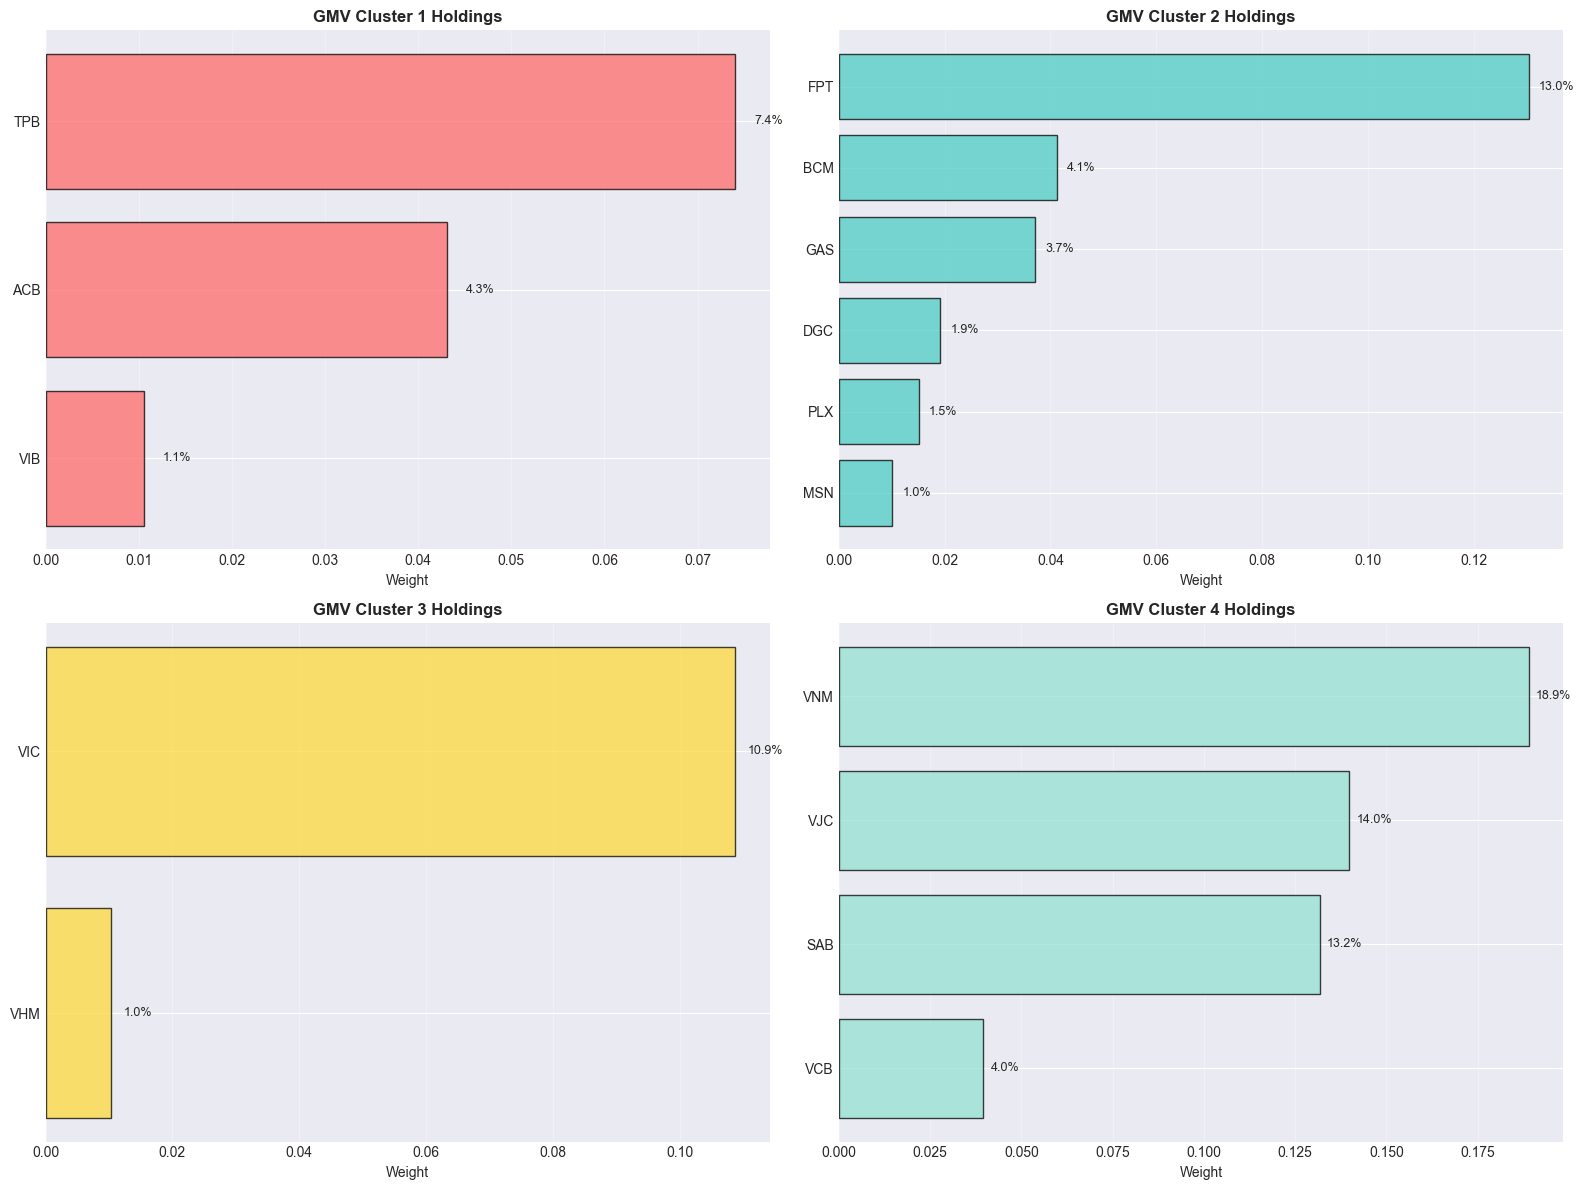

GMV per-cluster holding plots rendered.


In [14]:
if gmv_feasible and result is not None:
    selected_stocks = result[result["weight"] > selection_threshold].copy()
    selected_stocks = selected_stocks.sort_values(["cluster_id", "weight"], ascending=[True, False])
    selected_clusters = sorted(selected_stocks["cluster_id"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    cluster_colors = {1: "#FF6B6B", 2: "#4ECDC4", 3: "#FFD93D", 4: "#95E1D3"}

    for plot_idx, cid in enumerate(selected_clusters):
        ax = axes[plot_idx]
        cluster_stocks = selected_stocks[selected_stocks["cluster_id"] == cid].sort_values("weight", ascending=True)
        ax.barh(range(len(cluster_stocks)), cluster_stocks["weight"], color=cluster_colors.get(int(cid), "steelblue"), alpha=0.75, edgecolor="black")
        ax.set_yticks(range(len(cluster_stocks)))
        ax.set_yticklabels(cluster_stocks["ticker"], fontsize=10)
        ax.set_xlabel("Weight")
        ax.set_title(f"GMV Cluster {cid} Holdings", fontweight="bold")
        ax.grid(True, alpha=0.3, axis="x")
        for i, (_, row) in enumerate(cluster_stocks.iterrows()):
            ax.text(row["weight"] + 0.002, i, f"{row['weight']*100:.1f}%", va="center", fontsize=9)

    for j in range(len(selected_clusters), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    print("GMV per-cluster holding plots rendered.")
else:
    print("GMV per-cluster holding plots skipped because no feasibility-approved GMV solution is available.")


In [15]:
print("=" * 72)
print("SET UP THE AGGRESSIVE STATIC PROBLEM")
print("=" * 72)

output_file_agg = AGG_CANONICAL_PATH
agg_solver_status = "not_run"
agg_solver_name = "none"
agg_problem_value = np.nan
w_agg_opt = None
agg_feasibility = None
agg_feasible = False
agg_export_allowed = False
result_agg = None
result_agg_filtered = pd.DataFrame()
cluster_alloc_agg = pd.Series(dtype=float)
agg_ret = np.nan
agg_vol = np.nan
agg_sharpe_daily = np.nan
agg_sharpe_annual = np.nan
selected_target_return = None
frontier_results = []
frontier_shortlist = []

if not gmv_feasible:
    print("Aggressive setup skipped because the GMV solution did not pass feasibility checks.")
else:
    print("Aggressive formulation:")
    print("  - minimize w^T Sigma w")
    print("  - subject to mu^T w >= target_return")
    print("  - sum(w) = 1")
    print("  - w_i >= 0")
    print("  - aggressive-specific cluster caps")

    print("\nAggressive cluster caps:")
    for cid, cap in cluster_caps_aggressive_static.items():
        n_cluster_tickers = int((ticker_info["cluster_id"] == cid).sum())
        print(f"  - Cluster {cid}: cap <= {cap:.2f} ({cap*100:.0f}%), tickers = {n_cluster_tickers}")

    min_target = float(max(port_ret, np.nanmin(mu)))
    max_target = float(np.nanmax(mu))
    frontier_grid = np.linspace(min_target, max_target, 21)

    for target_return in frontier_grid:
        w_frontier = cp.Variable(n)
        frontier_constraints = [cp.sum(w_frontier) == 1, w_frontier >= 0, mu @ w_frontier >= float(target_return)]
        for cid, cap in cluster_caps_aggressive_static.items():
            idx = np.where(ticker_info["cluster_id"].to_numpy() == cid)[0]
            if len(idx) > 0:
                frontier_constraints.append(cp.sum(w_frontier[idx]) <= cap)
        frontier_problem = cp.Problem(cp.Minimize(cp.quad_form(w_frontier, Sigma)), frontier_constraints)
        solver_status, solver_name = solve_qp_problem(frontier_problem)
        w_value = None if w_frontier.value is None else np.asarray(w_frontier.value, dtype=float).reshape(-1)
        feasible = False
        if w_value is not None and solver_status in {"optimal", "optimal_inaccurate"}:
            feasible = bool(
                evaluate_feasibility(
                    weights=w_value,
                    ticker_info=ticker_info,
                    cluster_caps=cluster_caps_aggressive_static,
                    Sigma=Sigma,
                    vol_cap=None,
                )["feasible"]
            )
        frontier_results.append(
            {
                "target_return": float(target_return),
                "solver_status": solver_status,
                "solver_name": solver_name,
                "feasible": feasible,
            }
        )

    frontier_shortlist = build_aggressive_target_shortlist([row["target_return"] for row in frontier_results if row["feasible"]])
    selected_target_return = choose_highest_feasible_target(frontier_results)

    print(f"Daily target shortlist: {frontier_shortlist}")
    print(f"Selected daily target: {selected_target_return}")


SET UP THE AGGRESSIVE STATIC PROBLEM
Aggressive formulation:
  - minimize w^T Sigma w
  - subject to mu^T w >= target_return
  - sum(w) = 1
  - w_i >= 0
  - aggressive-specific cluster caps

Aggressive cluster caps:
  - Cluster 1: cap <= 0.60 (60%), tickers = 12
  - Cluster 2: cap <= 0.60 (60%), tickers = 10
  - Cluster 3: cap <= 0.30 (30%), tickers = 3
  - Cluster 4: cap <= 0.25 (25%), tickers = 4
Daily target shortlist: [0.0003459418, 0.0004289695, 0.0005119972, 0.0005950249, 0.0006780527, 0.0007610804, 0.0008441081, 0.0009271358, 0.0010101635, 0.0010931912, 0.001176219, 0.0012592467, 0.0013422744, 0.0014253021, 0.0015083298, 0.0015913575, 0.0016743852, 0.001757413, 0.0018404407]
Selected daily target: 0.0018404406805418545


In [16]:
print("=" * 72)
print("SOLVE THE AGGRESSIVE STATIC PROBLEM")
print("=" * 72)

if not gmv_feasible:
    print("Aggressive solve skipped because GMV was not feasibility-approved.")
elif selected_target_return is None:
    print("No feasibility-approved aggressive target was found on the daily-unit aggressive frontier.")
else:
    print("Running solver...")
    w_agg = cp.Variable(n)
    constraints_agg = [cp.sum(w_agg) == 1, w_agg >= 0, mu @ w_agg >= float(selected_target_return)]
    for cid, cap in cluster_caps_aggressive_static.items():
        idx = np.where(ticker_info["cluster_id"].to_numpy() == cid)[0]
        if len(idx) > 0:
            constraints_agg.append(cp.sum(w_agg[idx]) <= cap)

    problem_agg = cp.Problem(cp.Minimize(cp.quad_form(w_agg, Sigma)), constraints_agg)
    agg_solver_status, agg_solver_name = solve_qp_problem(problem_agg)
    agg_problem_value = float(problem_agg.value) if problem_agg.value is not None else np.nan
    w_agg_opt = None if w_agg.value is None else np.asarray(w_agg.value, dtype=float).reshape(-1)

    print(f"Solver status: {agg_solver_status}")
    print(f"Solver name:   {agg_solver_name}")
    print(f"Objective value (min variance): {agg_problem_value:.8f}" if not np.isnan(agg_problem_value) else "Objective value: unavailable")

    if w_agg_opt is None:
        print("No aggressive weights were returned by the solver.")
    else:
        agg_feasibility = evaluate_feasibility(
            weights=w_agg_opt,
            ticker_info=ticker_info,
            cluster_caps=cluster_caps_aggressive_static,
            Sigma=Sigma,
            vol_cap=None,
        )
        agg_feasible = bool(agg_feasibility["feasible"])
        agg_export_allowed = agg_solver_status in ["optimal", "optimal_inaccurate"] and agg_feasible

        result_agg = ticker_info.copy()
        result_agg["weight"] = w_agg_opt
        result_agg_filtered = result_agg[result_agg["weight"] > selection_threshold].sort_values("weight", ascending=False)
        cluster_alloc_agg = result_agg.groupby("cluster_id")["weight"].sum().sort_index()

        agg_ret = float(mu @ w_agg_opt)
        agg_vol = float(np.sqrt(max(w_agg_opt.T @ Sigma @ w_agg_opt, 0.0)))
        agg_sharpe_daily = agg_ret / agg_vol if agg_vol > 0 else np.nan
        agg_sharpe_annual = (agg_ret * trading_days) / (agg_vol * np.sqrt(trading_days)) if agg_vol > 0 else np.nan

        print_feasibility_report("Aggressive", agg_feasibility)
        print(f"Selected daily target-return: {selected_target_return:.8f}")
        print(f"Export decision: {'EXPORT' if agg_export_allowed else 'DO NOT EXPORT'}")
        print("\nAggressive metrics:")
        print(f"  - Annualized return proxy: {agg_ret * trading_days * 100:.2f}%")
        print(f"  - Annualized volatility:   {agg_vol * np.sqrt(trading_days) * 100:.2f}%")
        print(f"  - Annualized Sharpe (Rf=0): {agg_sharpe_annual:.4f}")

        if not agg_feasible:
            print("\nAggressive diagnostic: the solver returned weights, but the solution failed feasibility checks.")
            print("The canonical aggressive artifact will not be exported.")


SOLVE THE AGGRESSIVE STATIC PROBLEM
Running solver...
Solver status: optimal
Solver name:   OSQP
Objective value (min variance): 0.00040916
Aggressive feasibility status: PASS
  - n_nan_weights:         0
  - weight_sum_error:      0.00000000
  - min_weight:            -0.00000000
  - max_cluster_violation: 0.00000000
Selected daily target-return: 0.00184044
Export decision: EXPORT

Aggressive metrics:
  - Annualized return proxy: 46.38%
  - Annualized volatility:   32.11%
  - Annualized Sharpe (Rf=0): 1.4444


## Defensive vs Aggressive Comparison (Only if Aggressive Passes Feasibility)


In [17]:
if agg_export_allowed and result_agg is not None:
    print("=" * 80)
    print("DEFENSIVE VS AGGRESSIVE COMPARISON")
    print("=" * 80)

    comparison = pd.DataFrame(
        {
            "Strategy": ["GMV Defensive", "Aggressive Target-Return Min-Var"],
            "Annual Return (%)": [port_ret * trading_days * 100, agg_ret * trading_days * 100],
            "Annual Vol (%)": [port_vol * np.sqrt(trading_days) * 100, agg_vol * np.sqrt(trading_days) * 100],
            "Annual Sharpe (Rf=0)": [port_sharpe_annual, agg_sharpe_annual],
        }
    )
    print(comparison.to_string(index=False))

    ret_diff = (agg_ret - port_ret) * trading_days * 100
    vol_diff = (agg_vol - port_vol) * np.sqrt(trading_days) * 100
    sharpe_diff = agg_sharpe_annual - port_sharpe_annual

    print("\nDifference vs GMV:")
    print(f"  - Annual return difference: {ret_diff:+.2f}%")
    print(f"  - Annual volatility difference: {vol_diff:+.2f}%")
    print(f"  - Annual Sharpe difference: {sharpe_diff:+.4f}")
    print(f"  - Selected daily target-return: {selected_target_return:.8f}")

    print("\nCluster allocation comparison:")
    print(f"  {'Cluster':<10}{'GMV':<18}{'Aggressive':<18}{'Diff':<12}")
    print("  " + "-" * 56)
    for cid in sorted(cluster_alloc.index.astype(int)):
        gmv_w = float(cluster_alloc.get(cid, 0.0))
        agg_w = float(cluster_alloc_agg.get(cid, 0.0))
        diff = agg_w - gmv_w
        print(f"  {cid:<10}{gmv_w:>6.4f} ({gmv_w*100:5.1f}%)  {agg_w:>6.4f} ({agg_w*100:5.1f}%)  {diff:+.4f}")
else:
    print("Aggressive comparison skipped because there is no feasibility-approved aggressive solution.")
    if agg_feasibility is not None:
        print(f"  - Solver status: {agg_solver_status}")
        print(f"  - Feasibility status: {'PASS' if agg_feasible else 'FAIL'}")
        print(f"  - Max cluster violation: {agg_feasibility['max_cluster_violation']:.8f}")


DEFENSIVE VS AGGRESSIVE COMPARISON
                        Strategy  Annual Return (%)  Annual Vol (%)  Annual Sharpe (Rf=0)
                   GMV Defensive           8.717733       19.054086              0.457526
Aggressive Target-Return Min-Var          46.379105       32.110343              1.444367

Difference vs GMV:
  - Annual return difference: +37.66%
  - Annual volatility difference: +13.06%
  - Annual Sharpe difference: +0.9868
  - Selected daily target-return: 0.00184044

Cluster allocation comparison:
  Cluster   GMV               Aggressive        Diff        
  --------------------------------------------------------
  1         0.1279 ( 12.8%)  0.5344 ( 53.4%)  +0.4065
  2         0.2530 ( 25.3%)  0.4656 ( 46.6%)  +0.2126
  3         0.1191 ( 11.9%)  -0.0000 ( -0.0%)  -0.1191
  4         0.5000 ( 50.0%)  -0.0000 ( -0.0%)  -0.5000


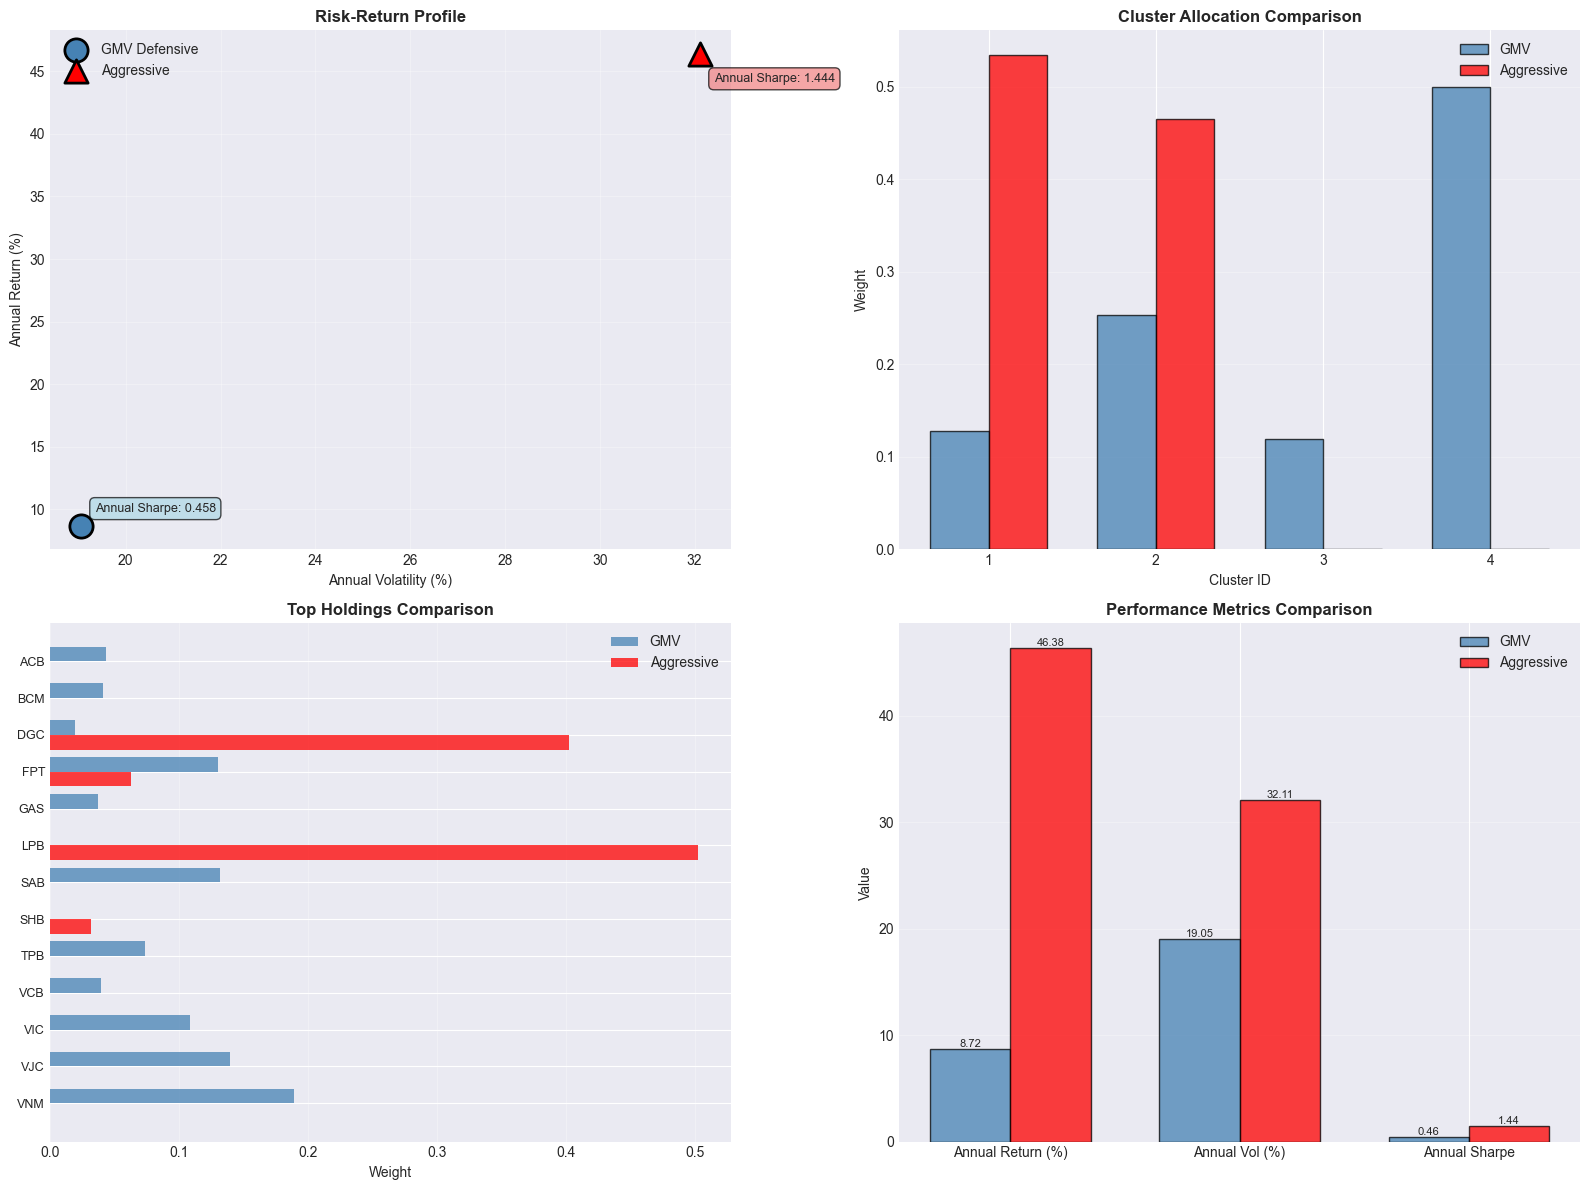

Comparison plots rendered.


In [18]:
if agg_export_allowed and result_agg is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    ax = axes[0, 0]
    ax.scatter([port_vol * np.sqrt(trading_days) * 100], [port_ret * trading_days * 100], s=280, c="steelblue", marker="o", edgecolors="black", linewidths=2, label="GMV Defensive")
    ax.scatter([agg_vol * np.sqrt(trading_days) * 100], [agg_ret * trading_days * 100], s=280, c="red", marker="^", edgecolors="black", linewidths=2, label="Aggressive")
    ax.set_xlabel("Annual Volatility (%)")
    ax.set_ylabel("Annual Return (%)")
    ax.set_title("Risk-Return Profile", fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.annotate(f"Annual Sharpe: {port_sharpe_annual:.3f}", xy=(port_vol * np.sqrt(trading_days) * 100, port_ret * trading_days * 100), xytext=(10, 10), textcoords="offset points", fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.7))
    ax.annotate(f"Annual Sharpe: {agg_sharpe_annual:.3f}", xy=(agg_vol * np.sqrt(trading_days) * 100, agg_ret * trading_days * 100), xytext=(10, -20), textcoords="offset points", fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="lightcoral", alpha=0.7))

    ax = axes[0, 1]
    x = np.arange(len(cluster_alloc))
    width = 0.35
    bars1 = ax.bar(x - width / 2, cluster_alloc.values, width, label="GMV", color="steelblue", alpha=0.75, edgecolor="black")
    bars2 = ax.bar(x + width / 2, cluster_alloc_agg.values, width, label="Aggressive", color="red", alpha=0.75, edgecolor="black")
    ax.set_xlabel("Cluster ID")
    ax.set_ylabel("Weight")
    ax.set_title("Cluster Allocation Comparison", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_alloc.index)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    ax = axes[1, 0]
    top_gmv = result_filtered.head(10)
    top_agg = result_agg_filtered.head(10)
    all_tickers = sorted(set(top_gmv["ticker"]).union(set(top_agg["ticker"])))[:15]
    gmv_weights = []
    agg_weights = []
    for ticker in all_tickers:
        gmv_match = result_filtered[result_filtered["ticker"] == ticker]["weight"].to_numpy()
        agg_match = result_agg_filtered[result_agg_filtered["ticker"] == ticker]["weight"].to_numpy()
        gmv_weights.append(float(gmv_match[0]) if len(gmv_match) else 0.0)
        agg_weights.append(float(agg_match[0]) if len(agg_match) else 0.0)
    y = np.arange(len(all_tickers))
    ax.barh(y - 0.2, gmv_weights, 0.4, label="GMV", color="steelblue", alpha=0.75)
    ax.barh(y + 0.2, agg_weights, 0.4, label="Aggressive", color="red", alpha=0.75)
    ax.set_yticks(y)
    ax.set_yticklabels(all_tickers, fontsize=9)
    ax.set_xlabel("Weight")
    ax.set_title("Top Holdings Comparison", fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="x")
    ax.invert_yaxis()

    ax = axes[1, 1]
    metrics = ["Annual Return (%)", "Annual Vol (%)", "Annual Sharpe"]
    gmv_vals = [port_ret * trading_days * 100, port_vol * np.sqrt(trading_days) * 100, port_sharpe_annual]
    agg_vals = [agg_ret * trading_days * 100, agg_vol * np.sqrt(trading_days) * 100, agg_sharpe_annual]
    x = np.arange(len(metrics))
    width = 0.35
    bars1 = ax.bar(x - width / 2, gmv_vals, width, label="GMV", color="steelblue", alpha=0.75, edgecolor="black")
    bars2 = ax.bar(x + width / 2, agg_vals, width, label="Aggressive", color="red", alpha=0.75, edgecolor="black")
    ax.set_ylabel("Value")
    ax.set_title("Performance Metrics Comparison", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2.0, height, f"{height:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()
    print("Comparison plots rendered.")
else:
    print("Comparison plots skipped because there is no feasibility-approved aggressive solution.")


In [19]:
aggressive_canonical = bool(agg_export_allowed and result_agg is not None)

if aggressive_canonical:
    portfolio_weights_agg = result_agg[["ticker", "cluster_id", "weight", "mean_ret", "std_ret"]].copy()
    portfolio_weights_agg = portfolio_weights_agg.sort_values(["cluster_id", "weight"], ascending=[True, False])
    output_file_agg.parent.mkdir(parents=True, exist_ok=True)
    portfolio_weights_agg.to_csv(output_file_agg, index=False)

    print("=" * 72)
    print("EXPORT AGGRESSIVE CANONICAL ARTIFACT")
    print("=" * 72)
    print(f"Exported: {output_file_agg}")
    print("Schema: ticker, cluster_id, weight, mean_ret, std_ret")
    print(f"Rows: {len(portfolio_weights_agg)}")
else:
    clear_canonical_if_present(output_file_agg)
    print("=" * 72)
    print("AGGRESSIVE EXPORT GATING")
    print("=" * 72)
    print("Aggressive canonical export was skipped.")
    print(f"Canonical aggressive path cleared for this non-canonical run: {output_file_agg}")
    if agg_feasibility is not None:
        print(f"  - Solver status: {agg_solver_status}")
        print(f"  - Feasibility status: {'PASS' if agg_feasible else 'FAIL'}")

static_status = build_static_artifact_status(
    gmv={
        "solver_status": gmv_solver_status,
        "feasible": bool(gmv_feasible),
        "exported": bool(gmv_export_allowed),
        "canonical_path": str(GMV_CANONICAL_PATH),
    },
    aggressive={
        "solver_status": agg_solver_status,
        "feasible": bool(agg_feasible),
        "exported": bool(aggressive_canonical),
        "canonical": bool(aggressive_canonical),
        "canonical_path": str(AGG_CANONICAL_PATH),
        "legacy_path": str(AGG_LEGACY_PATH),
        "reason_if_not_canonical": None if aggressive_canonical else "Aggressive static did not produce a feasibility-approved canonical output in this run.",
    },
)
write_static_artifact_status(STATUS_PATH, static_status)

print("=" * 72)
print("EXPORT STATIC ARTIFACT STATUS MANIFEST")
print("=" * 72)
print(f"Manifest path: {STATUS_PATH}")
print(json.dumps(static_status, indent=2))


EXPORT AGGRESSIVE CANONICAL ARTIFACT
Exported: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\portfolio_weights_aggressive.csv
Schema: ticker, cluster_id, weight, mean_ret, std_ret
Rows: 29
EXPORT STATIC ARTIFACT STATUS MANIFEST
Manifest path: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\static_artifact_status.json
{
  "version": 1,
  "run_timestamp": "2026-04-04T12:44:51.168807+00:00",
  "gmv": {
    "solver_status": "optimal",
    "feasible": true,
    "exported": true,
    "canonical_path": "D:\\Archive\\NCKH\\CODE\\vn30-ver1 - Copy\\data\\processed\\portfolio_weights_static.csv"
  },
  "aggressive": {
    "solver_status": "optimal",
    "feasible": true,
    "exported": true,
    "canonical": true,
    "canonical_path": "D:\\Archive\\NCKH\\CODE\\vn30-ver1 - Copy\\data\\processed\\portfolio_weights_aggressive.csv",
    "legacy_path": "D:\\Archive\\NCKH\\CODE\\vn30-ver1 - Copy\\data\\processed\\legacy\\portfolio_weights_aggressive_prefeasibility.csv",
    "reason_if_not

## Aggressive Portfolio Details (Only if Feasibility-Approved)


In [20]:
if agg_export_allowed and result_agg is not None:
    print("=" * 80)
    print("AGGRESSIVE PORTFOLIO DETAILS")
    print("=" * 80)

    agg_selected = result_agg[result_agg["weight"] > selection_threshold].sort_values("weight", ascending=False)
    print(f"Selected tickers: {len(agg_selected)}")
    print(f"Displayed weight sum: {agg_selected['weight'].sum():.4f}")

    for idx, (_, row) in enumerate(agg_selected.iterrows(), 1):
        ticker_sharpe_proxy = row['mean_ret'] / row['std_ret'] if row['std_ret'] > 0 else np.nan
        print(f"\n{idx}. {row['ticker']}")
        print(f"   - Cluster: {int(row['cluster_id'])}")
        print(f"   - Weight: {row['weight']:.4f} ({row['weight']*100:.2f}%)")
        print(f"   - Mean daily log-return estimate: {row['mean_ret']:.6f}")
        print(f"   - Annualized mean return proxy: {row['mean_ret']*trading_days*100:.2f}%")
        print(f"   - Daily volatility: {row['std_ret']:.6f}")
        print(f"   - Annualized volatility: {row['std_ret']*np.sqrt(trading_days)*100:.2f}%")
        print(f"   - Ticker Sharpe proxy (Rf=0): {ticker_sharpe_proxy:.4f}")

    agg_cluster_dist = agg_selected.groupby("cluster_id")["weight"].sum()
    print("\nAggressive cluster distribution:")
    for cid in sorted(agg_cluster_dist.index.astype(int)):
        alloc = float(agg_cluster_dist.loc[cid])
        n_stocks = int((agg_selected["cluster_id"] == cid).sum())
        print(f"  - Cluster {cid}: {alloc:.4f} ({alloc*100:.2f}%), displayed tickers = {n_stocks}")

    top3_weight = float(agg_selected.head(3)["weight"].sum())
    print("\nConcentration diagnostic:")
    print(f"  - Top 3 displayed weights: {top3_weight:.4f} ({top3_weight*100:.2f}%)")
else:
    print("Aggressive detail block skipped because there is no feasibility-approved aggressive solution.")


AGGRESSIVE PORTFOLIO DETAILS
Selected tickers: 4
Displayed weight sum: 1.0000

1. LPB
   - Cluster: 1
   - Weight: 0.5026 (50.26%)
   - Mean daily log-return estimate: 0.002006
   - Annualized mean return proxy: 50.56%
   - Daily volatility: 0.025968
   - Annualized volatility: 41.22%
   - Ticker Sharpe proxy (Rf=0): 0.0773

2. DGC
   - Cluster: 2
   - Weight: 0.4027 (40.27%)
   - Mean daily log-return estimate: 0.001790
   - Annualized mean return proxy: 45.10%
   - Daily volatility: 0.025859
   - Annualized volatility: 41.05%
   - Ticker Sharpe proxy (Rf=0): 0.0692

3. FPT
   - Cluster: 2
   - Weight: 0.0629 (6.29%)
   - Mean daily log-return estimate: 0.001054
   - Annualized mean return proxy: 26.57%
   - Daily volatility: 0.018127
   - Annualized volatility: 28.78%
   - Ticker Sharpe proxy (Rf=0): 0.0582

4. SHB
   - Cluster: 1
   - Weight: 0.0318 (3.18%)
   - Mean daily log-return estimate: 0.001414
   - Annualized mean return proxy: 35.62%
   - Daily volatility: 0.027292
   - An

## Step 10: Efficient Frontier Diagnostics

This section is **diagnostic / interpretive only**.

- It does **not** create a new canonical artifact for downstream notebooks.
- The frontier is generated by solving a discrete grid of target-return problems.
- The later "Max Sharpe" label refers to the **best point on that discrete frontier grid**, not a continuous exact maximize-Sharpe optimizer.


In [21]:
print("=" * 80)
print("PREPARE ANNUALIZED INPUTS FOR FRONTIER DIAGNOSTICS")
print("=" * 80)

mu_annual = mu * trading_days
Sigma_annual = Sigma * trading_days

print("Annualization formulas:")
print("  - mu_annual = mu * 252")
print("  - Sigma_annual = Sigma * 252")
print("  - vol_annual = vol_daily * sqrt(252)")

print("\nParameter ranges:")
print(f"  - mu_annual range: {mu_annual.min()*100:.2f}% to {mu_annual.max()*100:.2f}%")
print(f"  - asset vol range: {np.sqrt(np.diag(Sigma_annual)).min()*100:.2f}% to {np.sqrt(np.diag(Sigma_annual)).max()*100:.2f}%")

gmv_ret = float(w_opt @ mu_annual) if w_opt is not None else np.nan
gmv_vol = float(np.sqrt(max(w_opt @ Sigma_annual @ w_opt, 0.0))) if w_opt is not None else np.nan

print("\nGMV point used for diagnostics:")
print(f"  - Annual return proxy: {gmv_ret*100:.2f}%")
print(f"  - Annual volatility:   {gmv_vol*100:.2f}%")
print(f"  - Annual Sharpe (Rf=0): {((gmv_ret / gmv_vol) if gmv_vol > 0 else np.nan):.4f}")

if agg_export_allowed and w_agg_opt is not None:
    mu_agg = float(w_agg_opt @ mu_annual)
    vol_agg = float(np.sqrt(max(w_agg_opt @ Sigma_annual @ w_agg_opt, 0.0)))
    agg_frontier_sharpe = mu_agg / vol_agg if vol_agg > 0 else np.nan
    print("\nAggressive point used for diagnostics:")
    print(f"  - Annual return proxy: {mu_agg*100:.2f}%")
    print(f"  - Annual volatility:   {vol_agg*100:.2f}%")
    print(f"  - Annual Sharpe (Rf=0): {agg_frontier_sharpe:.4f}")
else:
    mu_agg = None
    vol_agg = None
    agg_frontier_sharpe = np.nan
    print("\nAggressive point is not included in the frontier diagnostics because there is no feasibility-approved aggressive solution.")

w_equal = np.ones(n) / n
eq_ret = float(w_equal @ mu_annual)
eq_vol = float(np.sqrt(max(w_equal @ Sigma_annual @ w_equal, 0.0)))
eq_sharpe = eq_ret / eq_vol if eq_vol > 0 else np.nan

print("\nEqual-weight benchmark:")
print(f"  - Annual return proxy: {eq_ret*100:.2f}%")
print(f"  - Annual volatility:   {eq_vol*100:.2f}%")
print(f"  - Annual Sharpe (Rf=0): {eq_sharpe:.4f}")


PREPARE ANNUALIZED INPUTS FOR FRONTIER DIAGNOSTICS
Annualization formulas:
  - mu_annual = mu * 252
  - Sigma_annual = Sigma * 252
  - vol_annual = vol_daily * sqrt(252)

Parameter ranges:
  - mu_annual range: -11.23% to 50.56%
  - asset vol range: 24.28% to 46.55%

GMV point used for diagnostics:
  - Annual return proxy: 8.72%
  - Annual volatility:   19.05%
  - Annual Sharpe (Rf=0): 0.4575

Aggressive point used for diagnostics:
  - Annual return proxy: 46.38%
  - Annual volatility:   32.11%
  - Annual Sharpe (Rf=0): 1.4444

Equal-weight benchmark:
  - Annual return proxy: 17.25%
  - Annual volatility:   23.99%
  - Annual Sharpe (Rf=0): 0.7190


In [22]:
print("=" * 80)
print("GENERATE DISCRETE FRONTIER PORTFOLIOS")
print("=" * 80)

min_return = gmv_ret
max_return = float(mu_annual.max())

print(f"Target return range: {min_return*100:.2f}% to {max_return*100:.2f}%")
print("The frontier is built by solving a grid of target-return problems.")

n_portfolios = 50
target_returns = np.linspace(min_return, max_return * 0.95, n_portfolios)

frontier_returns = []
frontier_risks = []
frontier_sharpes = []
frontier_weights = []

success_count = 0
fail_count = 0

for i, target_ret in enumerate(target_returns):
    try:
        w_frontier = cp.Variable(n)
        frontier_objective = cp.Minimize(cp.quad_form(w_frontier, Sigma_annual))
        frontier_constraints = [cp.sum(w_frontier) == 1, w_frontier >= 0, w_frontier @ mu_annual >= target_ret]

        for cid, cap in cluster_caps.items():
            idx = np.where(ticker_info["cluster_id"].to_numpy() == cid)[0]
            if len(idx) > 0:
                frontier_constraints.append(cp.sum(w_frontier[idx]) <= cap)

        frontier_problem = cp.Problem(frontier_objective, frontier_constraints)
        frontier_problem.solve(solver=cp.SCS, verbose=False)

        if frontier_problem.status in ["optimal", "optimal_inaccurate"] and w_frontier.value is not None:
            w_val = np.asarray(w_frontier.value, dtype=float).reshape(-1)
            port_ret = float(w_val @ mu_annual)
            port_vol = float(np.sqrt(max(w_val @ Sigma_annual @ w_val, 0.0)))
            port_sharpe = port_ret / port_vol if port_vol > 0 else np.nan
            frontier_returns.append(port_ret)
            frontier_risks.append(port_vol)
            frontier_sharpes.append(port_sharpe)
            frontier_weights.append(w_val.copy())
            success_count += 1
        else:
            fail_count += 1
            if fail_count >= 3:
                break
    except Exception:
        fail_count += 1
        if fail_count >= 3:
            break

    if (i + 1) % 10 == 0:
        print(f"Progress: {i+1}/{n_portfolios} targets | successful portfolios = {success_count}")

print("\nFrontier generation complete.")
print(f"  - Successful portfolios: {success_count}")
print(f"  - Failed / infeasible attempts: {fail_count}")

if frontier_returns:
    print(f"  - Return range: {min(frontier_returns)*100:.2f}% to {max(frontier_returns)*100:.2f}%")
    print(f"  - Risk range:   {min(frontier_risks)*100:.2f}% to {max(frontier_risks)*100:.2f}%")
    print(f"  - Sharpe range: {np.nanmin(frontier_sharpes):.4f} to {np.nanmax(frontier_sharpes):.4f}")
else:
    print("  - No frontier portfolios were generated.")


GENERATE DISCRETE FRONTIER PORTFOLIOS
Target return range: 8.72% to 50.56%
The frontier is built by solving a grid of target-return problems.
Progress: 10/50 targets | successful portfolios = 10
Progress: 20/50 targets | successful portfolios = 20


Progress: 30/50 targets | successful portfolios = 30


Progress: 40/50 targets | successful portfolios = 40

Frontier generation complete.
  - Successful portfolios: 46
  - Failed / infeasible attempts: 3
  - Return range: 8.72% to 44.83%
  - Risk range:   19.05% to 31.24%
  - Sharpe range: 0.4576 to 1.4387


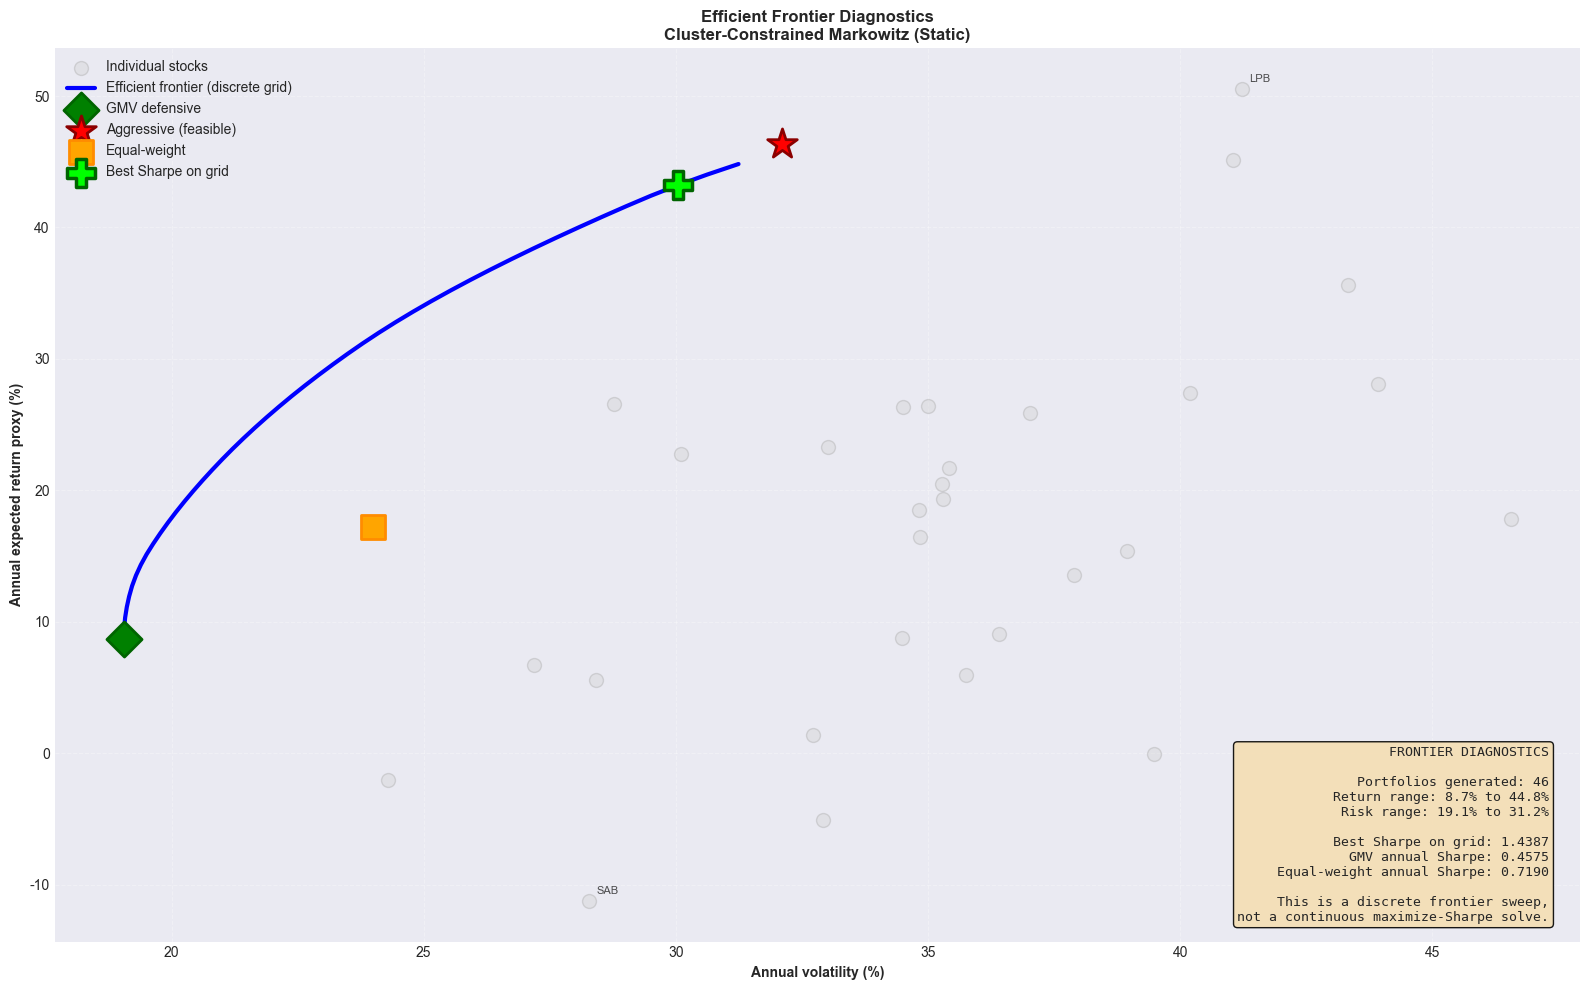

Efficient frontier diagnostic plot rendered.


In [23]:
if frontier_returns:
    fig, ax = plt.subplots(figsize=(16, 10))

    frontier_returns_pct = np.array(frontier_returns) * 100
    frontier_risks_pct = np.array(frontier_risks) * 100
    stock_returns = mu_annual * 100
    stock_vols = np.sqrt(np.diag(Sigma_annual)) * 100

    ax.scatter(stock_vols, stock_returns, alpha=0.4, s=100, c="lightgray", edgecolors="darkgray", linewidth=1.0, label="Individual stocks", zorder=1)
    for i in [int(mu_annual.argmax()), int(mu_annual.argmin())]:
        ticker = ticker_info.iloc[i]["ticker"]
        ax.annotate(ticker, xy=(stock_vols[i], stock_returns[i]), xytext=(5, 5), textcoords="offset points", fontsize=8, alpha=0.8)

    ax.plot(frontier_risks_pct, frontier_returns_pct, "b-", linewidth=3, label="Efficient frontier (discrete grid)", zorder=3)
    ax.scatter(gmv_vol * 100, gmv_ret * 100, marker="D", s=320, c="green", edgecolors="darkgreen", linewidth=2, label="GMV defensive", zorder=5)
    if mu_agg is not None and vol_agg is not None:
        ax.scatter(vol_agg * 100, mu_agg * 100, marker="*", s=500, c="red", edgecolors="darkred", linewidth=2, label="Aggressive (feasible)", zorder=5)
    ax.scatter(eq_vol * 100, eq_ret * 100, marker="s", s=280, c="orange", edgecolors="darkorange", linewidth=2, label="Equal-weight", zorder=5)

    max_sharpe_idx = int(np.nanargmax(frontier_sharpes))
    max_sharpe = float(frontier_sharpes[max_sharpe_idx])
    max_sharpe_ret = float(frontier_returns_pct[max_sharpe_idx])
    max_sharpe_vol = float(frontier_risks_pct[max_sharpe_idx])
    ax.scatter(max_sharpe_vol, max_sharpe_ret, marker="P", s=420, c="lime", edgecolors="darkgreen", linewidth=2.5, label="Best Sharpe on grid", zorder=6)

    ax.set_xlabel("Annual volatility (%)", fontweight="bold")
    ax.set_ylabel("Annual expected return proxy (%)", fontweight="bold")
    ax.set_title("Efficient Frontier Diagnostics\nCluster-Constrained Markowitz (Static)", fontweight="bold")
    ax.legend(loc="upper left", framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle="--")

    info_text = "\n".join([
        "FRONTIER DIAGNOSTICS",
        "",
        f"Portfolios generated: {len(frontier_returns)}",
        f"Return range: {min(frontier_returns_pct):.1f}% to {max(frontier_returns_pct):.1f}%",
        f"Risk range: {min(frontier_risks_pct):.1f}% to {max(frontier_risks_pct):.1f}%",
        "",
        f"Best Sharpe on grid: {max_sharpe:.4f}",
        f"GMV annual Sharpe: {gmv_ret / gmv_vol:.4f}",
        f"Equal-weight annual Sharpe: {eq_sharpe:.4f}",
        "",
        "This is a discrete frontier sweep,",
        "not a continuous maximize-Sharpe solve.",
    ])
    ax.text(0.98, 0.02, info_text, transform=ax.transAxes, fontsize=9.5, verticalalignment="bottom", horizontalalignment="right", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.9, edgecolor="black"), family="monospace")

    plt.tight_layout()
    plt.show()
    print("Efficient frontier diagnostic plot rendered.")
else:
    print("Efficient frontier plot skipped because no frontier portfolios were generated.")


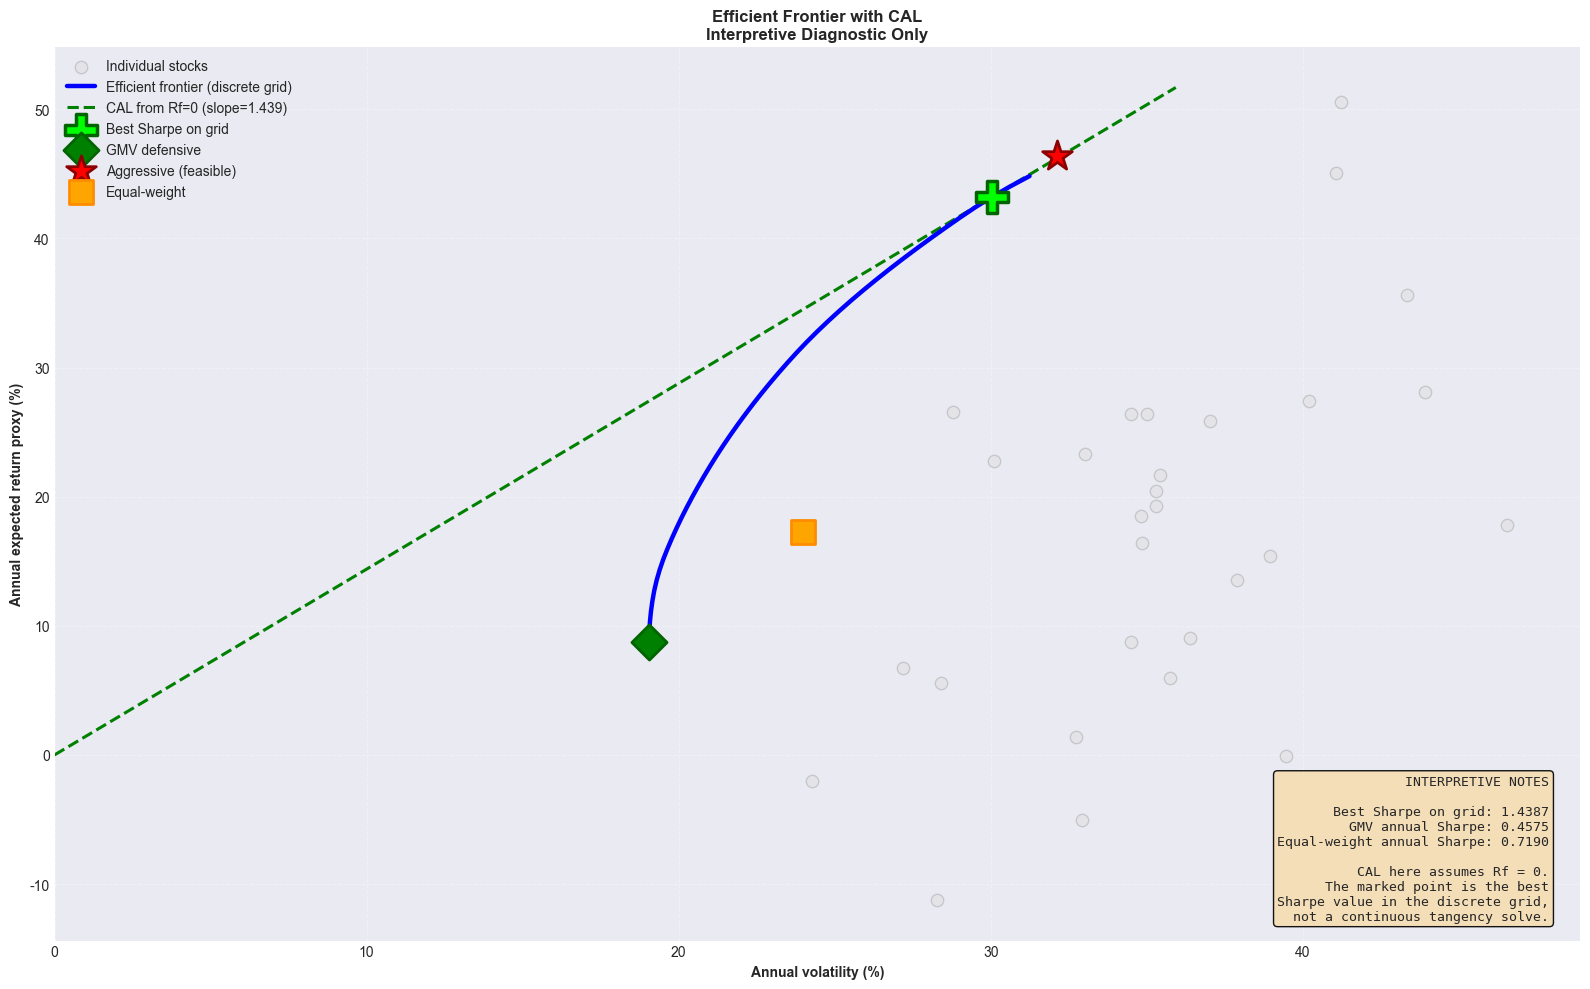

Efficient frontier + CAL diagnostic plot rendered.
Best Sharpe on the discrete grid: 1.4387 at (30.0%, 43.2%)


In [24]:
if frontier_returns:
    fig, ax = plt.subplots(figsize=(16, 10))

    frontier_returns_pct = np.array(frontier_returns) * 100
    frontier_risks_pct = np.array(frontier_risks) * 100
    stock_returns = mu_annual * 100
    stock_vols = np.sqrt(np.diag(Sigma_annual)) * 100

    ax.scatter(stock_vols, stock_returns, alpha=0.3, s=80, c="lightgray", edgecolors="gray", linewidth=1.0, label="Individual stocks", zorder=1)
    ax.plot(frontier_risks_pct, frontier_returns_pct, "b-", linewidth=3.2, label="Efficient frontier (discrete grid)", zorder=3)

    max_sharpe_idx = int(np.nanargmax(frontier_sharpes))
    max_sharpe = float(frontier_sharpes[max_sharpe_idx])
    max_sharpe_ret = float(frontier_returns_pct[max_sharpe_idx])
    max_sharpe_vol = float(frontier_risks_pct[max_sharpe_idx])

    cal_x = np.linspace(0, max(frontier_risks_pct) * 1.15, 100)
    cal_y = max_sharpe * cal_x
    ax.plot(cal_x, cal_y, "g--", linewidth=2.2, label=f"CAL from Rf=0 (slope={max_sharpe:.3f})", zorder=2)

    ax.scatter(max_sharpe_vol, max_sharpe_ret, marker="P", s=520, c="lime", edgecolors="darkgreen", linewidth=2.5, label="Best Sharpe on grid", zorder=7)
    ax.scatter(gmv_vol * 100, gmv_ret * 100, marker="D", s=320, c="green", edgecolors="darkgreen", linewidth=2, label="GMV defensive", zorder=5)
    if mu_agg is not None and vol_agg is not None:
        ax.scatter(vol_agg * 100, mu_agg * 100, marker="*", s=500, c="red", edgecolors="darkred", linewidth=2, label="Aggressive (feasible)", zorder=5)
    ax.scatter(eq_vol * 100, eq_ret * 100, marker="s", s=280, c="orange", edgecolors="darkorange", linewidth=2, label="Equal-weight", zorder=5)

    ax.set_xlabel("Annual volatility (%)", fontweight="bold")
    ax.set_ylabel("Annual expected return proxy (%)", fontweight="bold")
    ax.set_title("Efficient Frontier with CAL\nInterpretive Diagnostic Only", fontweight="bold")
    ax.legend(loc="upper left", framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_xlim(left=0)

    info_text = "\n".join([
        "INTERPRETIVE NOTES",
        "",
        f"Best Sharpe on grid: {max_sharpe:.4f}",
        f"GMV annual Sharpe: {gmv_ret / gmv_vol:.4f}",
        f"Equal-weight annual Sharpe: {eq_sharpe:.4f}",
        "",
        "CAL here assumes Rf = 0.",
        "The marked point is the best",
        "Sharpe value in the discrete grid,",
        "not a continuous tangency solve.",
    ])
    ax.text(0.98, 0.02, info_text, transform=ax.transAxes, fontsize=9.5, verticalalignment="bottom", horizontalalignment="right", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.92, edgecolor="black"), family="monospace")

    plt.tight_layout()
    plt.show()
    print("Efficient frontier + CAL diagnostic plot rendered.")
    print(f"Best Sharpe on the discrete grid: {max_sharpe:.4f} at ({max_sharpe_vol:.1f}%, {max_sharpe_ret:.1f}%)")
else:
    print("Efficient frontier + CAL plot skipped because no frontier portfolios were generated.")


In [25]:
print("=" * 80)
print("STATIC PORTFOLIO OPTIMIZATION - FINAL NOTEBOOK SUMMARY")
print("=" * 80)
print("Inputs used:")
print("  - return_matrix_clean.csv")
print("  - cov_matrix.csv")
print("  - ticker_clusters_enriched.csv")
print("\nGMV defensive status:")
print(f"  - Solver status:      {gmv_solver_status}")
print(f"  - Solver name:        {gmv_solver_name}")
print(f"  - Feasibility status: {'PASS' if gmv_feasible else 'FAIL'}")
print(f"  - Export decision:    {'EXPORTED' if gmv_export_allowed else 'NOT EXPORTED'}")
print(f"  - Canonical path:     {output_file}")
print("\nAggressive status:")
print(f"  - Solver status:      {agg_solver_status}")
print(f"  - Solver name:        {agg_solver_name}")
print(f"  - Feasibility status: {'PASS' if agg_feasible else 'FAIL'}")
print(f"  - Export decision:    {'EXPORTED' if agg_export_allowed else 'NOT EXPORTED'}")
print(f"  - Canonical path:     {output_file_agg}")
print(f"  - Legacy path:        {AGG_LEGACY_PATH}")
if selected_target_return is None:
    print("  - Selected daily target-return: unavailable")
else:
    print(f"  - Selected daily target-return: {selected_target_return:.8f}")
if not agg_export_allowed:
    print("  - Canonical aggressive path is cleared when the run is non-canonical.")
print("\nArtifact handoff:")
print(f"  - GMV export path:            {output_file}")
print(f"  - Aggressive export path:     {output_file_agg}")
print(f"  - Static artifact manifest:   {STATUS_PATH}")
print(f"  - Legacy migration executed:  {migrated_legacy_once}")
print("\nNext notebook:")
print("  - 07_backtest_static_portfolio.ipynb")
print("\nInterpretation note:")
print("  - The efficient frontier block is diagnostic only.")
print("  - If aggressive fails feasibility, it must not be interpreted as a clean portfolio result.")
print("=" * 80)


STATIC PORTFOLIO OPTIMIZATION - FINAL NOTEBOOK SUMMARY
Inputs used:
  - return_matrix_clean.csv
  - cov_matrix.csv
  - ticker_clusters_enriched.csv

GMV defensive status:
  - Solver status:      optimal
  - Solver name:        OSQP
  - Feasibility status: PASS
  - Export decision:    EXPORTED
  - Canonical path:     D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\portfolio_weights_static.csv

Aggressive status:
  - Solver status:      optimal
  - Solver name:        OSQP
  - Feasibility status: PASS
  - Export decision:    EXPORTED
  - Canonical path:     D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\portfolio_weights_aggressive.csv
  - Legacy path:        D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\legacy\portfolio_weights_aggressive_prefeasibility.csv
  - Selected daily target-return: 0.00184044

Artifact handoff:
  - GMV export path:            D:\Archive\NCKH\CODE\vn30-ver1 - Copy\data\processed\portfolio_weights_static.csv
  - Aggressive export path:     D:\Ar